### Middleware

Middleware helps you control and customize how an agent behaves while it is running. It can be used for things like:

* Monitoring agent activity using logs, analytics, or debugging tools.
* Modifying prompts, choosing tools dynamically, or formatting responses.
* Handling retries, fallback mechanisms, and stopping execution when needed.
* Enforcing rate limits, security checks, guardrails, or detecting sensitive data like PII.

- https://reference.langchain.com/python/langchain-core/messages/utils/count_tokens_approximately
- https://reference.langchain.com/python/langchain/middleware
- https://docs.langchain.com/oss/python/langchain/middleware/overview

In [1]:
from langchain_groq import ChatGroq
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from dotenv import load_dotenv
load_dotenv()

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

c:\Users\Administrator\Downloads\b150-genaiops\18_Langchain\.venv\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

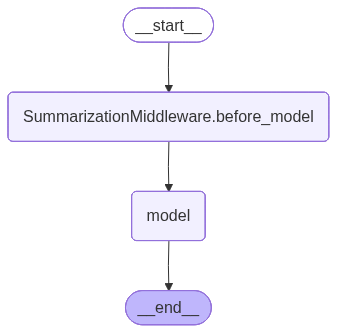

In [3]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)

agent = create_agent(
    model=llm,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)
agent

In [4]:
### Run with thread id
config={"configurable":{"thread_id":"test-1"}}

In [5]:
# Alternative test data
questions = [
    "What is 5+5?",
    "What is 10*9?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")


Messages: {'messages': [HumanMessage(content='What is 5+5?', additional_kwargs={}, response_metadata={}, id='5d7dba93-4a99-40e1-961d-f6062428a6b1'), AIMessage(content='5 + 5 = 10.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 42, 'total_tokens': 51, 'completion_time': 0.020138152, 'completion_tokens_details': None, 'prompt_time': 0.00247425, 'prompt_tokens_details': None, 'queue_time': 0.036876129, 'total_time': 0.022612402}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e12ad-3af8-7e60-9d73-7898ae6959d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 9, 'total_tokens': 51})]}
Messages: 2
Messages: {'messages': [HumanMessage(content='What is 5+5?', additional_kwargs={}, response_metadata={}, id='5d7dba93-4a99-40e1-961d-f6062428a6b1'), AIMess

## token Size

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""


agent=create_agent(
    model="groq:openai/gpt-oss-120b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:llama-3.1-8b-instant",
            trigger=("tokens",550),
            keep=("tokens",200),
        ),
    ],
    system_prompt="""
        Keep answers under 80 words.
        Never generate tables.
        Never ask followup questions.
        Call tool only once.
        """,
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

In [7]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~85 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='3aa93a17-070c-42b9-a73e-e8d3cdaea06a'), AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants hotels in Paris. Use search_hotels tool. Need to keep answer under 80 words, no tables, no follow-up. Call tool once with city "Paris".', 'tool_calls': [{'id': 'fc_ca66cbc2-2d85-4419-b462-3e077f200e07', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 159, 'total_tokens': 224, 'completion_time': 0.136523705, 'completion_tokens_details': {'reasoning_tokens': 37}, 'prompt_time': 0.0060524, 'prompt_tokens_details': None, 'queue_time': 0.076188885, 'total_time': 0.142576105}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_acbbc9c4c3', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_p

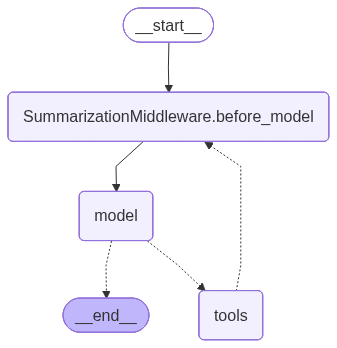

In [8]:
agent

### Fraction

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

# Groq LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# Agent
agent = create_agent(
    model=llm,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("fraction", 0.005), # .5% = ~640 token of model limit
            keep=("fraction", 0.002), # 0.2% = ~ 250 tokens
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Approx token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test data
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )

    tokens = count_tokens(response["messages"])
    
    # Change according to model context window
    fraction = tokens / 128000

    print(
        f"{city}: ~{tokens} tokens "
        f"({fraction:.4%}), "
        f"{len(response['messages'])} msgs"
    )

    print(response["messages"])

Paris: ~59 tokens (0.0461%), 6 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='bb9d892f-1857-47ff-a6af-cc1738f7d254'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'yk1hwdc48', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 210, 'total_tokens': 225, 'completion_time': 0.035484019, 'completion_tokens_details': None, 'prompt_time': 0.021678787, 'prompt_tokens_details': None, 'queue_time': 0.144667477, 'total_time': 0.057162806}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e123e-b07e-7980-b834-78f9fb657b16-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'yk1hwdc48', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metada

### Human In the Loop MiddleWare

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [10]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq

# Groq model
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)

agent = create_agent(
    model=llm,
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": { ## interrupt while sending emails
                    "allowed_decisions": [
                        "approve",
                        "edit",
                        "reject"
                    ]
                },
                "read_email_tool": False, # no interrupt while reading emails
            }
        )
    ]
)

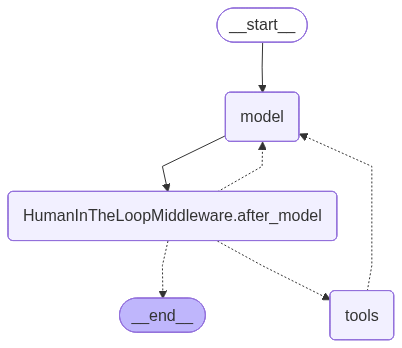

In [11]:
agent

In [12]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [13]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='713b8b5a-a777-47ed-aa30-c41a52a5f0f2'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'yk1ey1tsr', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 309, 'total_tokens': 341, 'completion_time': 0.054498157, 'completion_tokens_details': None, 'prompt_time': 0.043384954, 'prompt_tokens_details': None, 'queue_time': 0.077478234, 'total_time': 0.097883111}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e12b8-15ce-7e82-b78a-6e1ed0e00916-0', tool_calls=[{'name': 'send_email_tool', 'args': {'b

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='713b8b5a-a777-47ed-aa30-c41a52a5f0f2'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'yk1ey1tsr', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 309, 'total_tokens': 341, 'completion_time': 0.054498157, 'completion_tokens_details': None, 'prompt_time': 0.043384954, 'prompt_tokens_details': None, 'queue_time': 0.077478234, 'total_time': 0.097883111}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e12b8-15ce-7e82-b78a-6e1ed0e00916-0', tool_calls=[{'name': 'send_email_tool', 'args': {'body': 'How are you?', 'recipient': 'john@test.com', 'subject': 'Hello'}, 'id': 'yk1ey1tsr', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 309, 'output_tokens': 32, 'total_tokens': 341})],
 '__interrupt__': [Interrupt(value={'action_requests': [{'name': 'send_email_tool', 'args': {'body': 'How are you?', 'recipient': 'john@test.com', 'subject': 'Hello'}, 'description': "Tool execution requires approval\n\nTool: send_email_tool\nArgs: {'body': 'How are you?', 'recipient': 'john@test.com', 'subject': 'Hello'}"}], 'review_configs': [{'action_name': 'send_email_tool', 'allowed_decisions': ['approve', 'edit', 'reject']}]}, id='78c858ffb0ccdabbce6865899c9b75a9')]}

In [14]:
# to execute something in langraph we need command
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: Email sent to john@test.com with subject 'Hello' and body 'How are you?'


In [15]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='713b8b5a-a777-47ed-aa30-c41a52a5f0f2'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'yk1ey1tsr', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 309, 'total_tokens': 341, 'completion_time': 0.054498157, 'completion_tokens_details': None, 'prompt_time': 0.043384954, 'prompt_tokens_details': None, 'queue_time': 0.077478234, 'total_time': 0.097883111}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e12b8-15ce-7e82-b78a-6e1ed0e00916-0', tool_calls=[{'name': 'send_email_tool', 'args': {'b

### Reject

In [24]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from langchain_core.tools import tool

# Groq model
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)

@tool
def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

@tool
def send_email_tool(
    recipient: str,
    subject: str,
    body: str
) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=llm,
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": [
                        "approve",
                        "edit",
                        "reject",
                    ],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [25]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [26]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: 


In [27]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='59bc800e-d349-46e5-8c22-4e7d8f3d9b33'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zyk6nfcb7', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 309, 'total_tokens': 341, 'completion_time': 0.045273372, 'completion_tokens_details': None, 'prompt_time': 0.052277478, 'prompt_tokens_details': None, 'queue_time': 0.036972138, 'total_time': 0.09755085}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e124c-4bee-7a32-bfe9-5ec212a03c46-0', tool_calls=[{'name': 'send_email_tool', 'args': {'bo

### Editing

In [21]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from langchain_core.tools import tool

# Groq LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)

@tool
def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

@tool
def send_email_tool(
    recipient: str,
    subject: str,
    body: str
) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=llm,
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": [
                        "approve",
                        "edit",
                        "reject"
                    ],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [22]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [23]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='0f8e35c4-e7b4-4beb-be04-4ee0682f315c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'rajf7620c', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 307, 'total_tokens': 337, 'completion_time': 0.061498879, 'completion_tokens_details': None, 'prompt_time': 0.028872789, 'prompt_tokens_details': None, 'queue_time': 0.05419681, 'total_time': 0.090371668}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d1c-5072-7ce3-8337-48e8e7956444-0', tool_calls=[{'name': 'send_email_tool', 'args': {'body': 'Hello'

In [24]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: 


In [25]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='0f8e35c4-e7b4-4beb-be04-4ee0682f315c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'rajf7620c', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 307, 'total_tokens': 337, 'completion_time': 0.061498879, 'completion_tokens_details': None, 'prompt_time': 0.028872789, 'prompt_tokens_details': None, 'queue_time': 0.05419681, 'total_time': 0.090371668}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d1c-5072-7ce3-8337-48e8e7956444-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'ar